In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sstats
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
import matplotlib.patches as mpatches
from statsmodels.stats.multitest import multipletests

In [2]:
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)
pd.set_option('display.width', 1000)

For Spearman: Using % Change for the biannual data by calcluating the linear least-squares regression for 24 months 
and then dividing slope / mean values *100 for the percentage change for those two years

### Preparing Data

In [3]:
def compute_trend_test(values):

    vals = np.array(values, dtype=float)
    vals = vals[~np.isnan(vals)]   # drop any NaN years

    if len(vals) < 3:
        return None  
        
    mean_val = vals.mean()
    if mean_val == 0:
        return None   # can't divide by zero

    time_index = np.arange(len(vals))   # [0, 1, 2, 3, 4, 5] for 6 years

    slope, intercept, r, p, se = sstats.linregress(time_index, vals)

    pct_trend = (slope / mean_val) * 100

    return pct_trend

In [4]:
def read_data(country):
    #the updated indicator list from Creating_final_fixed_idnicator_csv.ipynb
    df = pd.read_csv(rf"..\..\data\ouput\country_analysis\v5_indicators\{country}\{country}_prepped_indicators_stat_update.csv")
    #also calculating the normalized values for cross reference later on
    df["active_normalized"] =  (df["active_users"] - df["active_users"].min())/(df["active_users"].max()-df["active_users"].min())
    df["new_contrib_normalized"] =  (df["total_new_contrib"] - df["total_new_contrib"].min())/(df["total_new_contrib"].max()-df["total_new_contrib"].min())
    df["changesets_normalized"] =  (df["changesets"] - df["changesets"].min())/(df["changesets"].max()-df["changesets"].min())
    df = df.astype({"changesets": float}) #necessary for pct_change aggregation
    return df

In [5]:
def aggregating_data(country):
    df = read_data(country)
    
    #the three biannual timeframes
    total23 = df.loc[(df["months"] <="2025-12" ) & (df["months"] >"2023-12" )]
    total21 = df.loc[(df["months"] <="2023-12" ) & (df["months"] >"2021-12" )]
    total20 = df.loc[(df["months"] <="2021-12" ) & (df["months"] >"2019-12" )]

    #getting the pct_change vlaues for each timeframe (from 24 months values)
    pct_trend_active_23 = compute_trend_test(total23["active_users"])
    pct_trend_active_21  = compute_trend_test(total21["active_users"])
    pct_trend_active_20  = compute_trend_test(total20["active_users"])

    pct_trend_changesets_23 = compute_trend_test(total23["changesets"])
    pct_trend_changesets_21  = compute_trend_test(total21["changesets"])
    pct_trend_changesets_20  = compute_trend_test(total20["changesets"])

    pct_trend_new_contrib_23 = compute_trend_test(total23["total_new_contrib"])
    pct_trend_new_contrib_21  = compute_trend_test(total21["total_new_contrib"])
    pct_trend_new_contrib_20  = compute_trend_test(total20["total_new_contrib"])
    
    total_mean23 = total23.drop(columns={"months"}).mean()
    total_mean23_df = total_mean23.to_frame().T
    total_mean23_df["pct_trend_active"] =pct_trend_active_23
    total_mean23_df["pct_trend_changesets"] =pct_trend_changesets_23
    total_mean23_df["pct_trend_new_contrib"] =pct_trend_new_contrib_23
    total_mean23_df["country"] =f"{country}"
    total_mean23_df["time_frame"] ="24_25"
    
    total_mean21 = total21.drop(columns={"months"}).mean()
    total_mean21_df = total_mean21.to_frame().T
    total_mean21_df["pct_trend_active"] =pct_trend_active_21
    total_mean21_df["pct_trend_changesets"] =pct_trend_changesets_21
    total_mean21_df["pct_trend_new_contrib"] =pct_trend_new_contrib_21
    total_mean21_df["country"] =f"{country}"
    total_mean21_df["time_frame"] ="22_23"
    
    total_mean20 = total20.drop(columns={"months"}).mean()
    total_mean20_df = total_mean20.to_frame().T
    total_mean20_df["pct_trend_active"] =pct_trend_active_20
    total_mean20_df["pct_trend_changesets"] =pct_trend_changesets_20
    total_mean20_df["pct_trend_new_contrib"] =pct_trend_new_contrib_20
    total_mean20_df["country"] =f"{country}"
    total_mean20_df["time_frame"] ="20_21"
    
    result = pd.concat([total_mean20_df, total_mean21_df, total_mean23_df])
    return result
    

In [6]:
countries = ["ALB", "BGD", "BOL", "BTN", "BRN", "CYP", "ECU", "ETH", "B35", "GRC", "HUN", "IND", "KEN", "KOR",
             "MAR", "MKD", "MNE", "NGA", "NZ1", "PNG", "SAU", "TUR", "TZA", "US1", "VNM"
            ]

In [7]:
dfs = []

for c in countries:
    df = aggregating_data(c)
    dfs.append(df)

result_all = pd.concat(dfs, ignore_index=True)

In [8]:
result_all.columns

Index(['contributors', 'changesets', 'edits', 'mean_degree', 'active_users', 'total_new_contrib', 'changeset_comments_ai', 'ratio_active_users_ai', 'changesets_corporate_share', 'contributors_corporate_share', 'changesets_humanitarian_share', 'contributors_humanitarian_share', 'edits_corporate_share', 'edits_humanitarian_share', 'edits_ai_share', 'changesets_ai_share', 'contributors_ai_share', 'contributors_prolific_share_ai', 'contributors_casual_share_ai', 'contributors_inactive_share_ai', 'building_changesets_share', 'highway_changesets_share', 'building_changesets_ai_share', 'highway_changesets_ai_share', 'new_contributors_ai_share', 'notes_length', 'contributors_prolific_share_ai_total', 'contributors_casual_share_ai_total', 'contributors_inactive_share_ai_total', 'retention_rate_ai', 'new_contrib_ai_share', 'active_normalized', 'new_contrib_normalized', 'changesets_normalized', 'pct_trend_active', 'pct_trend_changesets', 'pct_trend_new_contrib', 'country', 'time_frame'], dtype='o

#### Extra: One big correlation table

In [9]:
def aggregating_data_big(country):
    df = read_data(country)
    
    #the three biannual timeframes
    total = df.loc[(df["months"] <="2025-12" ) & (df["months"] >"2019-12" )]

    #getting the pct_change vlaues for each timeframe (from 24 months values)
    pct_trend_active = compute_trend_test(total["active_users"])
    pct_trend_changesets = compute_trend_test(total["changesets"])
    pct_trend_new_contrib = compute_trend_test(total["total_new_contrib"])

    sum_cols = ['contributors', 'changesets', 'edits']

    total_prep = total.drop(columns={"months"})
    total_mean = total_prep.mean()
    total_mean[sum_cols] = total_prep[sum_cols].sum()
    
    total_mean_df = total_mean.to_frame().T
    total_mean_df["pct_trend_active"] =pct_trend_active
    total_mean_df["pct_trend_changesets"] =pct_trend_changesets
    total_mean_df["pct_trend_new_contrib"] =pct_trend_new_contrib
    total_mean_df["country"] =f"{country}"

    
    return total_mean_df
    

In [10]:
dfs_big = []

for c in countries:
    dfb = aggregating_data_big(c)
    dfs_big.append(dfb)

result_all_big = pd.concat(dfs_big, ignore_index=True)

In [11]:
result_all_big.to_csv("../../data/ouput/v2/spatial/allyear_indicator_csv_top25.csv", index=False)

In [42]:
big_cor = create_corr_table(result_all_big)
pivotbig = big_cor.pivot(index="predictor", columns="outcome", values="r")
pivotbig_labeled = rename_pivot(pivotbig, labels_spearman, labels_predictors)


In [43]:
# Pivot the p-values in the same way as your correlation values
pivot_p = big_cor.pivot(
    index="predictor",
    columns="outcome",
    values="p"
)

pivotp_labeled = rename_pivot(pivot_p, labels_spearman, labels_predictors)

# Convert p-values to significance stars
def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

stars = pivotp_labeled.map(significance_stars)
annot = pivotp_labeled.round(2).astype(str) + stars
# Create the annotation dataframe


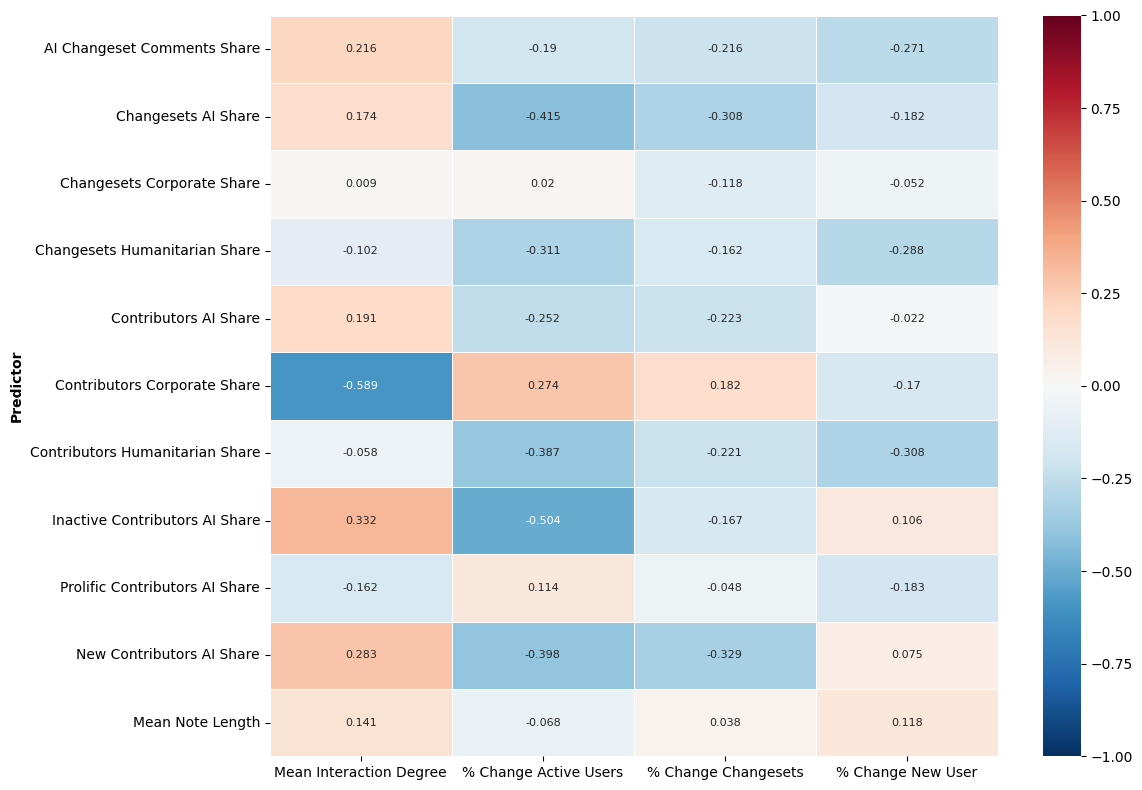

In [45]:
# Plot
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    pivotbig_labeled,
    annot=True,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8},
)

ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

ax.set_ylabel("Predictor", fontsize=10, fontweight="bold")
ax.set_xlabel("")

plt.tight_layout()
fig.savefig("../../results/statistical_evaluation/spearman_pct_big_finalv2_top25.png", bbox_inches="tight")

plt.show()

### Correlation

In [13]:
def create_corr_table(df):
    valid_cols = [c for c in OUTCOME_COLS + PREDICTOR_COLS if c in df.columns]
    monthly_data = df[valid_cols]
    #monthly_data = monthly_data.fillna(0)

    rows = []
    for pred in PREDICTOR_COLS:
        if pred not in monthly_data.columns:
            continue
        for out in OUTCOME_COLS:
            if out not in monthly_data.columns:
                continue
            valid = monthly_data[[pred, out]].dropna()
            if len(valid) < 3:
                continue
            r, p = sstats.spearmanr(valid[pred], valid[out])
            rows.append({
                "predictor": pred,
                "outcome":   out,
                "r":         round(r, 3),
                "p":         round(p, 3),
                "n":         len(valid),
            })
    
    corr_table = pd.DataFrame(rows)
    return corr_table

In [14]:
OUTCOME_COLS = [
   'pct_trend_active', 'pct_trend_new_contrib','pct_trend_changesets', 'mean_degree'
]


In [15]:
#selection of indicators
PREDICTOR_COLS = [
    'changeset_comments_ai',
    'changesets_corporate_share', 'contributors_corporate_share', 'changesets_humanitarian_share', 'contributors_humanitarian_share',
    'changesets_ai_share', 'contributors_ai_share', 'contributors_prolific_share_ai', 'contributors_inactive_share_ai', 'new_contributors_ai_share', 
    'notes_length',
]

In [16]:
tf_45 = result_all.loc[result_all["time_frame"]=="24_25"]
tf_23 = result_all.loc[result_all["time_frame"]=="22_23"]
tf_01 = result_all.loc[result_all["time_frame"]=="20_21"]

In [17]:
corr_table_01 = create_corr_table(tf_01)
corr_table_23 = create_corr_table(tf_23)
corr_table_45 = create_corr_table(tf_45)

In [18]:
pivot01 = corr_table_01.pivot(index="predictor", columns="outcome", values="r")
pivot23 = corr_table_23.pivot(index="predictor", columns="outcome", values="r")
pivot45 = corr_table_45.pivot(index="predictor", columns="outcome", values="r")

##### Additionally creating one df per outcome

In [19]:
p01 = pivot01.copy().reset_index()
p23 = pivot23.copy().reset_index()
p45 = pivot45.copy().reset_index()


In [20]:
mean_degree = p01[["predictor","mean_degree"]].rename(columns={"mean_degree":"2020-2021"}).merge(p23[["predictor","mean_degree"]].rename(columns={"mean_degree":"2022-2023"}), on = "predictor")
mean_degree = mean_degree.merge(p45[["predictor","mean_degree"]].rename(columns={"mean_degree":"2024-2025"}), on = "predictor")

In [21]:
pct_trend_active = p01[["predictor","pct_trend_active"]].rename(columns={"pct_trend_active":"2020-2021"}).merge(p23[["predictor","pct_trend_active"]].rename(columns={"pct_trend_active":"2022-2023"}), on = "predictor")
pct_trend_active = pct_trend_active.merge(p45[["predictor","pct_trend_active"]].rename(columns={"pct_trend_active":"2024-2025"}), on = "predictor")

In [22]:
pct_trend_changesets = p01[["predictor","pct_trend_changesets"]].rename(columns={"pct_trend_changesets":"2020-2021"}).merge(p23[["predictor","pct_trend_changesets"]].rename(columns={"pct_trend_changesets":"2022-2023"}), on = "predictor")
pct_trend_changesets = pct_trend_changesets.merge(p45[["predictor","pct_trend_changesets"]].rename(columns={"pct_trend_changesets":"2024-2025"}), on = "predictor")

In [23]:
pct_trend_new_contrib = p01[["predictor","pct_trend_new_contrib"]].rename(columns={"pct_trend_new_contrib":"2020-2021"}).merge(p23[["predictor","pct_trend_new_contrib"]].rename(columns={"pct_trend_new_contrib":"2022-2023"}), on = "predictor")
pct_trend_new_contrib = pct_trend_new_contrib.merge(p45[["predictor","pct_trend_new_contrib"]].rename(columns={"pct_trend_new_contrib":"2024-2025"}), on = "predictor")

In [24]:
pct_trend_new_contrib = pct_trend_new_contrib.set_index('predictor')
pct_trend_changesets = pct_trend_changesets.set_index('predictor')
mean_degree = mean_degree.set_index('predictor')
pct_trend_active = pct_trend_active.set_index('predictor')


##### Labeling

In [25]:
labels_spearman = {
    'pct_trend_active' : '% Change Active Users',
    'pct_trend_new_contrib' : '% Change New User',
    'pct_trend_changesets' : '% Change Changesets',
    'mean_degree' : 'Mean Interaction Degree',
}
labels_predictors = {
    'changeset_comments_ai' : 'AI Changeset Comments Share',
    'changesets_corporate_share' : 'Changesets Corporate Share',
    'contributors_corporate_share' : 'Contributors Corporate Share',
    'changesets_humanitarian_share' : 'Changesets Humanitarian Share', 
    'contributors_humanitarian_share' : 'Contributors Humanitarian Share',
    'changesets_ai_share' : 'Changesets AI Share',
    'contributors_ai_share' : 'Contributors AI Share', 
    'contributors_prolific_share_ai' : 'Prolific Contributors AI Share',
    'contributors_inactive_share_ai' : 'Inactive Contributors AI Share', 
    'new_contributors_ai_share' : 'New Contributors AI Share', 
    'notes_length' : 'Mean Note Length',
    'contributors_prolific_share_ai_total' : 'Prolific Contributors AI Share of Total', 
    'contributors_inactive_share_ai_total' : 'Inactive Contributors AI Share of Total'
}

In [26]:
# Apply to each pivot before plotting
def rename_pivot(pivot, col_labels, row_labels):
    return (pivot
            .rename(columns=col_labels)   # outcome labels (x-axis)
            .rename(index=row_labels))    # predictor labels (y-axis)

pivot01_labeled = rename_pivot(pivot01, labels_spearman, labels_predictors)
pivot23_labeled = rename_pivot(pivot23, labels_spearman, labels_predictors)
pivot45_labeled = rename_pivot(pivot45, labels_spearman, labels_predictors)

pct_trend_new_contrib_l = rename_pivot(pct_trend_new_contrib, labels_spearman, labels_predictors)
pct_trend_active_l = rename_pivot(pct_trend_active, labels_spearman, labels_predictors)
mean_degree_l = rename_pivot(mean_degree, labels_spearman, labels_predictors)
pct_trend_changesets_l = rename_pivot(pct_trend_changesets, labels_spearman, labels_predictors)

In [27]:
# ── Pivot p-values alongside r-values ──────────────────────────────────────
pval01 = corr_table_01.pivot(index="predictor", columns="outcome", values="p")
pval23 = corr_table_23.pivot(index="predictor", columns="outcome", values="p")
pval45 = corr_table_45.pivot(index="predictor", columns="outcome", values="p")

pval01 = rename_pivot(pval01, labels_spearman, labels_predictors)
pval23 = rename_pivot(pval23, labels_spearman, labels_predictors)
pval45 = rename_pivot(pval45, labels_spearman, labels_predictors)

# make sure the p-value pivots have the same row/col order as your r pivots
pval01 = pval01.loc[pivot01_labeled.index, pivot01_labeled.columns]
pval23 = pval23.loc[pivot23_labeled.index, pivot23_labeled.columns]
pval45 = pval45.loc[pivot45_labeled.index, pivot45_labeled.columns]

# ── Helper: convert r + p into annotation strings like "0.42*" ─────────────
def stars(p):
    if pd.isna(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

def make_annot(r_df, p_df):
    annot = r_df.copy().astype(str)
    for i in r_df.index:
        for j in r_df.columns:
            r_val = r_df.loc[i, j]
            if pd.isna(r_val):
                annot.loc[i, j] = ""
            else:
                annot.loc[i, j] = f"{r_val:.2f}{stars(p_df.loc[i, j])}"
    return annot

annot01 = make_annot(pivot01_labeled, pval01)
annot23 = make_annot(pivot23_labeled, pval23)
annot45 = make_annot(pivot45_labeled, pval45)

In [28]:
def add_multiple_testing_correction(corr_table, group_col=None, method="fdr_bh", alpha=0.05):
    """
    Add multiple-testing-corrected p-values to a Spearman correlation table.

    corr_table : DataFrame with a 'p' column (output of create_corr_table)
    group_col  : column to correct WITHIN (e.g. 'timeframe'). If None,
                 correction is applied across the whole table at once (pooled).
    method     : 'fdr_bh' (Benjamini-Hochberg, recommended default) or
                 'bonferroni' (more conservative)
    """
    corr_table = corr_table.copy()

    if group_col is None:
        rej, p_adj, _, _ = multipletests(corr_table["p"], alpha=alpha, method=method)
        corr_table["p_adj"] = p_adj
        corr_table["sig_adj"] = rej
    else:
        corr_table["p_adj"] = None
        corr_table["sig_adj"] = None
        for grp, idx in corr_table.groupby(group_col).groups.items():
            p_vals = corr_table.loc[idx, "p"]
            rej, p_adj, _, _ = multipletests(p_vals, alpha=alpha, method=method)
            corr_table.loc[idx, "p_adj"] = p_adj
            corr_table.loc[idx, "sig_adj"] = rej

    corr_table["p_adj"] = corr_table["p_adj"].astype(float)
    corr_table["sig_adj"] = corr_table["sig_adj"].astype(bool)
    return corr_table

In [29]:
corr_table_01["timeframe"] = "2020_2021"
corr_table_23["timeframe"] = "2022_2023"
corr_table_45["timeframe"] = "2024_2025"

In [30]:
tables = [corr_table_01, corr_table_23, corr_table_45]

In [31]:
all_tables = pd.concat(tables, ignore_index=True)

In [32]:
corrected = add_multiple_testing_correction(all_tables)

In [36]:
corrected

,predictor,outcome,r,p,n,timeframe,p_adj,sig_adj
0,changeset_comments_ai,pct_trend_active,-0.101,0.630,25,2020_2021,0.828594,False
1,changeset_comments_ai,pct_trend_new_contrib,0.032,0.878,25,2020_2021,0.959129,False
2,changeset_comments_ai,pct_trend_changesets,-0.055,0.795,25,2020_2021,0.908069,False
3,changeset_comments_ai,mean_degree,0.260,0.210,25,2020_2021,0.620151,False
4,changesets_corporate_share,pct_trend_active,0.220,0.291,25,2020_2021,0.651051,False
5,changesets_corporate_share,pct_trend_new_contrib,0.576,0.003,25,2020_2021,0.396000,False
6,changesets_corporate_share,pct_trend_changesets,0.107,0.611,25,2020_2021,0.828594,False
7,changesets_corporate_share,mean_degree,-0.095,0.653,25,2020_2021,0.845059,False
8,contributors_corporate_share,pct_trend_active,0.184,0.379,25,2020_2021,0.744986,False
9,contributors_corporate_share,pct_trend_new_contrib,0.367,0.071,25,2020_2021,0.468600,False


##### Plotting

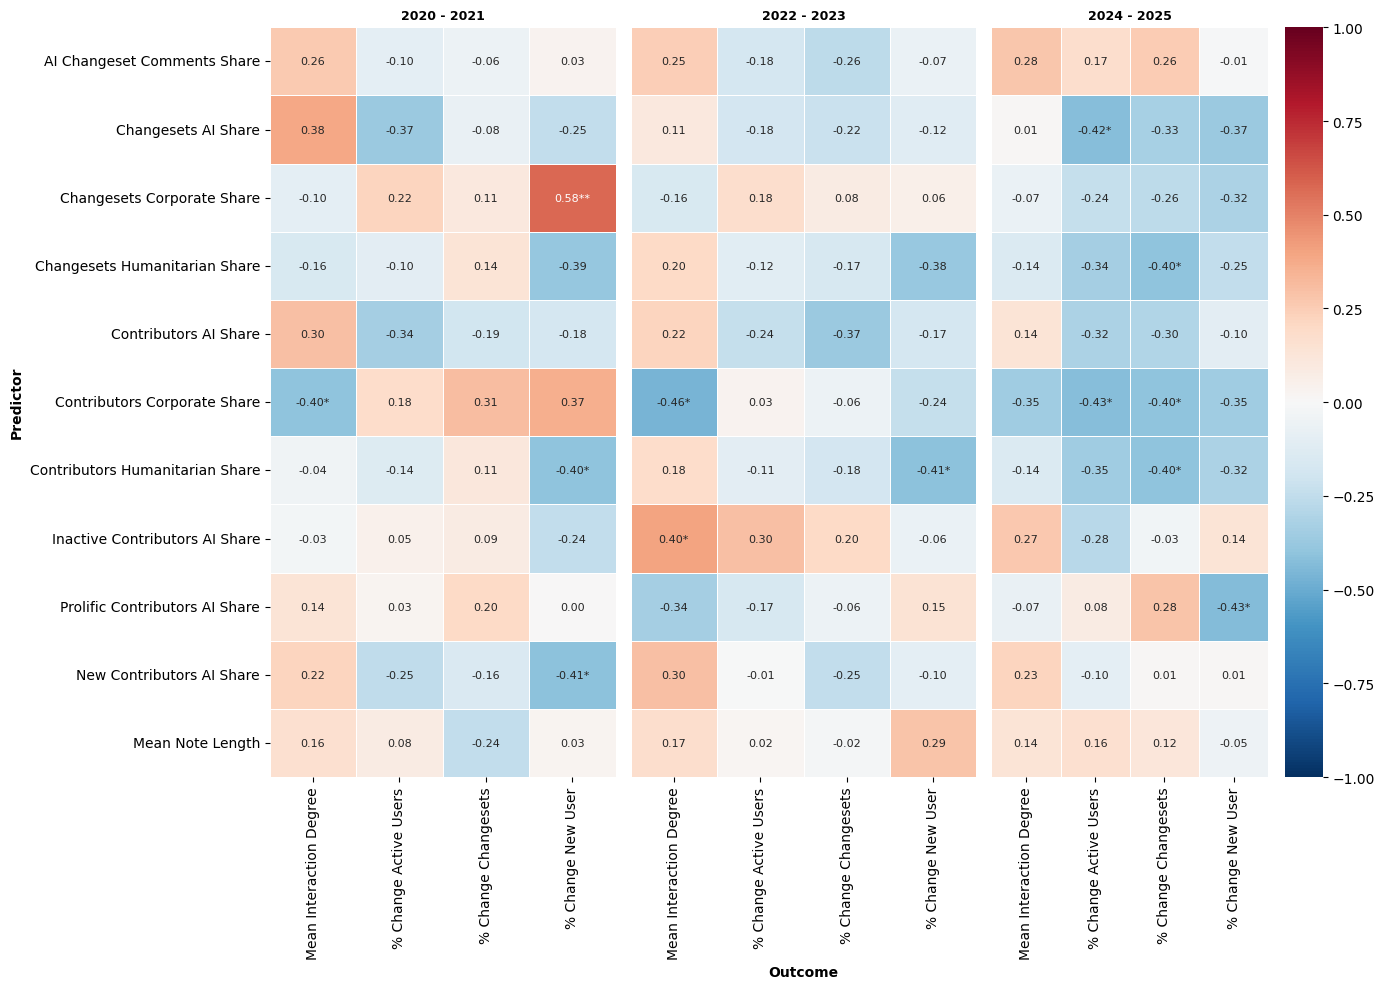

In [41]:
# ── Heatmap of all three periods ──────────────────────────────────────────────────────────

fig, ax = plt.subplots(1, 3, figsize=(14,10) )

#fig.suptitle("Spearman Correlation of selected AI and growth Indicators against Sustainability Outcomes (r-values)", fontsize=12, fontweight = "bold")
for a in ax:
    a.tick_params(axis="x", labelsize=10)
    a.tick_params(axis="y", labelsize=10)
    
ax1 = ax[0]
ax1.set_title( "2020 - 2021", fontsize=9, fontweight = "bold")
sns.heatmap(
    pivot01_labeled, annot=annot01, fmt="",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax1, annot_kws={"size": 8},cbar=False, 
)
ax1.set_ylabel("Predictor", fontsize = 10, fontweight = "bold")
ax1.set_xlabel("")

ax2 = ax[1]
ax2.set_title( "2022 - 2023", fontsize=9, fontweight = "bold")
sns.heatmap(
    pivot23_labeled, annot=annot23, fmt="",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax2, annot_kws={"size": 8}, cbar=False, 
)
ax2.set_ylabel("")
ax2.set_xlabel("Outcome", fontsize = 10, fontweight = "bold" )
ax2.tick_params(axis="y", left=False, labelleft=False)

ax3 = ax[2]
ax3.set_title( "2024 - 2025", fontsize=9, fontweight = "bold")
sns.heatmap(
    pivot45_labeled, annot=annot45, fmt="",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax3, annot_kws={"size": 8}
)

ax3.set_ylabel("")
ax3.set_xlabel("")
ax3.tick_params(axis="y", left=False, labelleft=False)

plt.tight_layout()

fig.savefig("../../results/statistical_evaluation/spearman_pct_change_outcomes_vfinalnew_top25.png", bbox_inches="tight")

plt.show()

In [38]:
# ── Build p-value pivots (same shape as your r pivots) ─────────────────────
pval01 = corr_table_01.pivot(index="predictor", columns="outcome", values="p")
pval23 = corr_table_23.pivot(index="predictor", columns="outcome", values="p")
pval45 = corr_table_45.pivot(index="predictor", columns="outcome", values="p")

pp01 = pval01.copy().reset_index()
pp23 = pval23.copy().reset_index()
pp45 = pval45.copy().reset_index()

def regroup(pp01, pp23, pp45, col):
    out = pp01[["predictor", col]].rename(columns={col: "2020-2021"}).merge(
          pp23[["predictor", col]].rename(columns={col: "2022-2023"}), on="predictor")
    out = out.merge(
          pp45[["predictor", col]].rename(columns={col: "2024-2025"}), on="predictor")
    return out.set_index("predictor")

p_mean_degree            = regroup(pp01, pp23, pp45, "mean_degree")
p_pct_trend_active       = regroup(pp01, pp23, pp45, "pct_trend_active")
p_pct_trend_changesets   = regroup(pp01, pp23, pp45, "pct_trend_changesets")
p_pct_trend_new_contrib  = regroup(pp01, pp23, pp45, "pct_trend_new_contrib")

p_mean_degree = rename_pivot(p_mean_degree, labels_spearman, labels_predictors)
p_pct_trend_active = rename_pivot(p_pct_trend_active, labels_spearman, labels_predictors)
p_pct_trend_changesets = rename_pivot(p_pct_trend_changesets, labels_spearman, labels_predictors)
p_pct_trend_new_contrib = rename_pivot(p_pct_trend_new_contrib, labels_spearman, labels_predictors)

# ── Star helper ──────────────────────────────────────────────────────────
def stars(p):
    if pd.isna(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""

def make_annot(r_df, p_df):
    p_df = p_df.loc[r_df.index, r_df.columns]  # align order
    annot = r_df.copy().astype(str)
    for i in r_df.index:
        for j in r_df.columns:
            r_val = r_df.loc[i, j]
            annot.loc[i, j] = "" if pd.isna(r_val) else f"{r_val:.2f}{stars(p_df.loc[i, j])}"
    return annot

annot_mean_degree           = make_annot(mean_degree_l, p_mean_degree)
annot_pct_trend_active      = make_annot(pct_trend_active_l, p_pct_trend_active)
annot_pct_trend_changesets  = make_annot(pct_trend_changesets_l, p_pct_trend_changesets)
annot_pct_trend_new_contrib = make_annot(pct_trend_new_contrib_l, p_pct_trend_new_contrib)

annot_dfs = {
    "% Change New Contributors": annot_pct_trend_new_contrib,
    "% Change Active Users":     annot_pct_trend_active,
    "% Change Changesets":       annot_pct_trend_changesets,
    "Mean Interaction Degree":   annot_mean_degree,
}

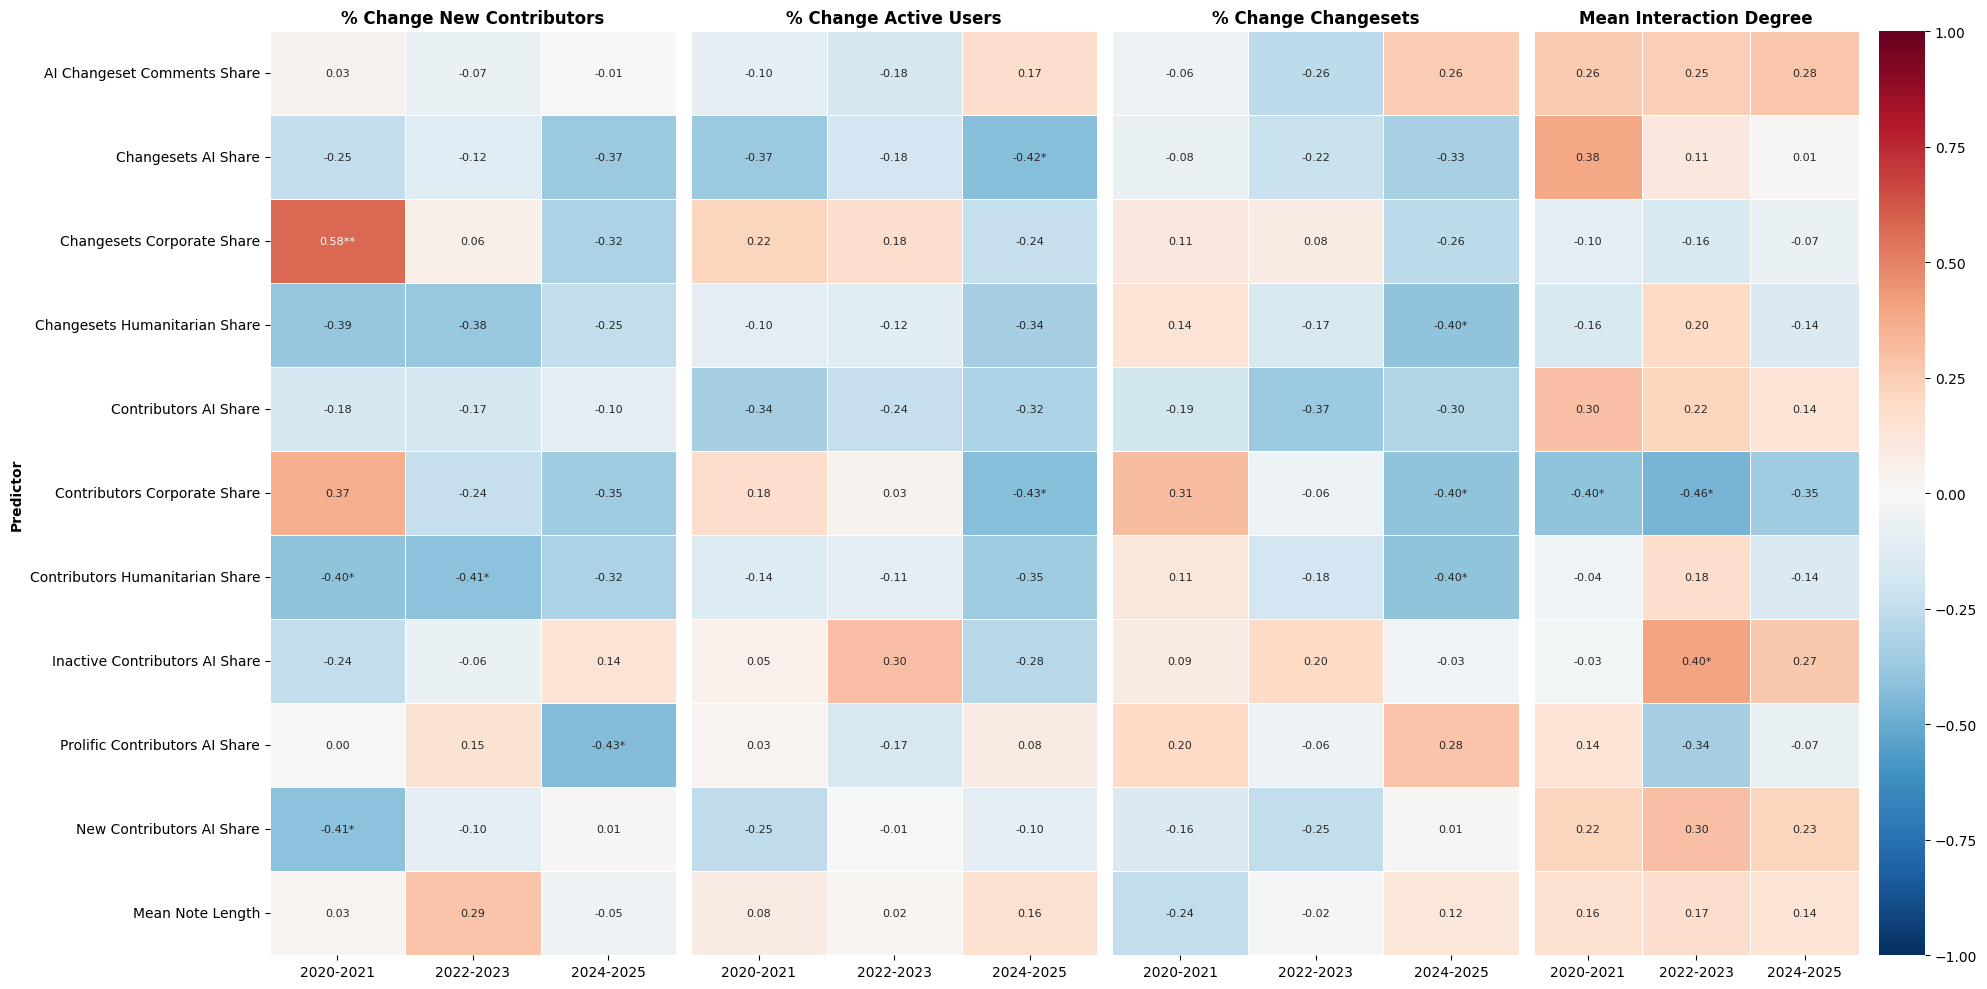

In [40]:
outcome_dfs = {
    "% Change New Contributors": pct_trend_new_contrib_l,
    "% Change Active Users":     pct_trend_active_l,
    "% Change Changesets":       pct_trend_changesets_l,
    "Mean Interaction Degree":   mean_degree_l,
}
# ── Plot ──────────────────────────────────────────────────────────────────────

n = len(outcome_dfs)
fig, axes = plt.subplots(1, 4, figsize=(20, 10))

for i, (outcome_label, df) in enumerate(outcome_dfs.items()):
    ax = axes[i]
    sns.heatmap(
        df,
        annot=annot_dfs[outcome_label], 
        fmt="",
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax,
        annot_kws={"size": 8},
        cbar=(i == n - 1),   
        #cbar_kws={"shrink": 0.6, "label": "Spearman r"} if i == n - 1 else {},
    )
    
    ax.set_title(outcome_label, fontsize=12, fontweight="bold", pad=6)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=10
                  )

    # Only show y-axis labels on first panel
    if i == 0:
        ax.set_ylabel("Predictor", fontsize=10, fontweight="bold")
        ax.tick_params(axis="y", labelsize=10)
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", left=False, labelleft=False)

#fig.suptitle("Spearman Correlation", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig("../../results/statistical_evaluation/spearman_pctchange_yearly_vfinalnew_pvaluespng_top25", bbox_inches="tight", dpi=300)
plt.show()

#### Check with min-maxed Values

In [17]:
OUTCOME_COLS = [
   'mean_degree','active_normalized', 'new_contrib_normalized', 'changesets_normalized', 
]


In [18]:
corr_table_01 = create_corr_table(tf_01)
corr_table_23 = create_corr_table(tf_23)
corr_table_45 = create_corr_table(tf_45)

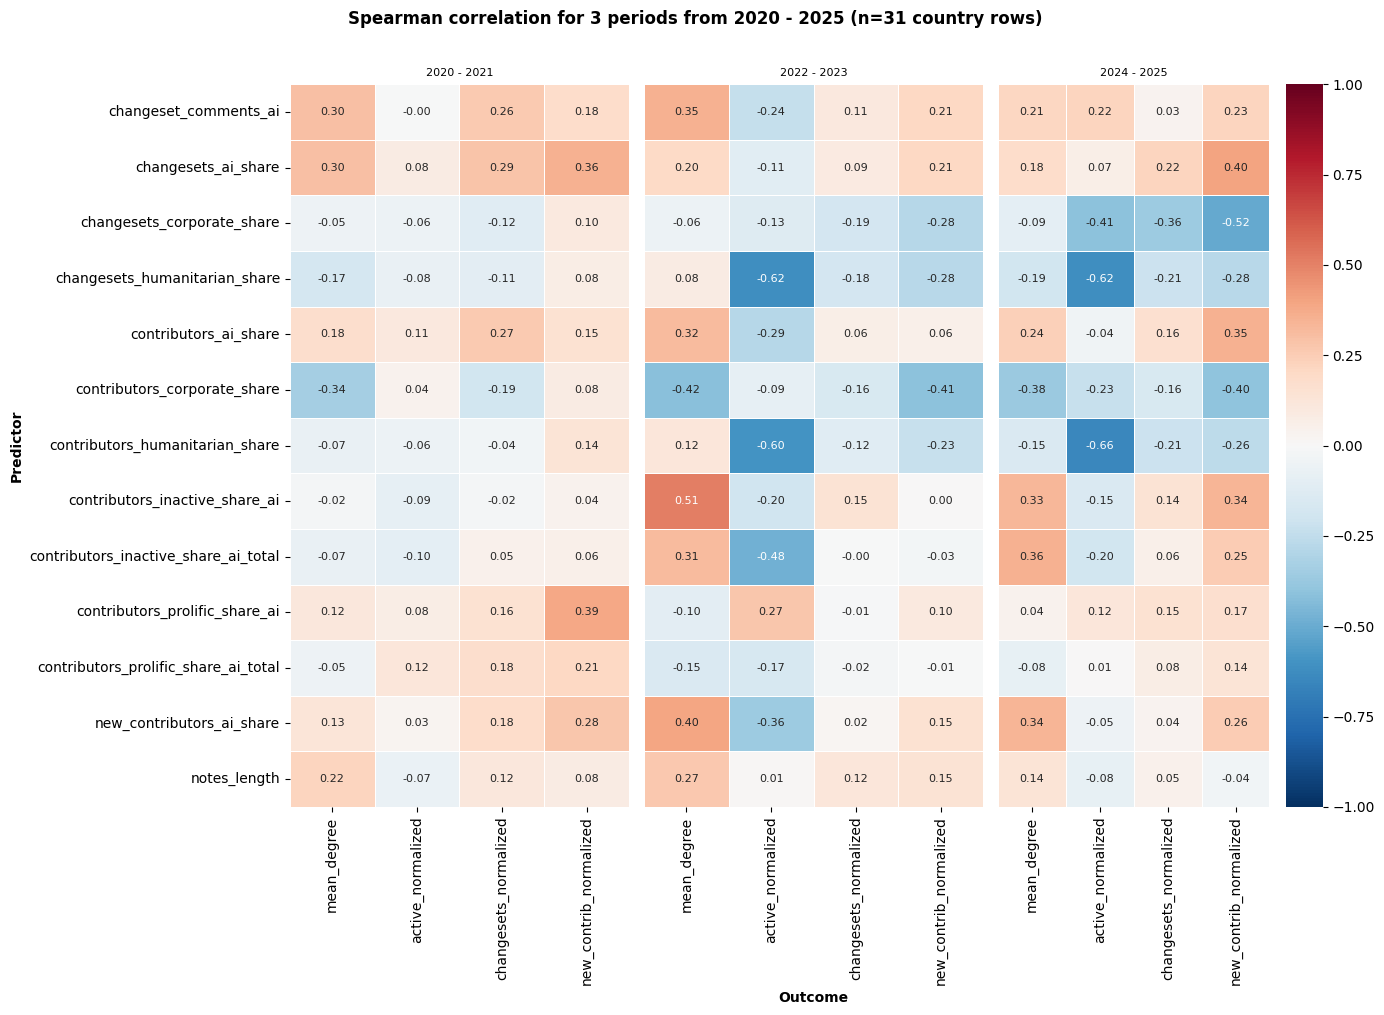

In [19]:
# ── Heatmap of all three periods ──────────────────────────────────────────────────────────

pivot01 = corr_table_01.pivot(index="predictor", columns="outcome", values="r")
pivot01 = pivot01[['mean_degree', 'active_normalized', 'changesets_normalized', 'new_contrib_normalized']]
pivot23 = corr_table_23.pivot(index="predictor", columns="outcome", values="r")
pivot23 = pivot23[['mean_degree', 'active_normalized', 'changesets_normalized', 'new_contrib_normalized']]
pivot45 = corr_table_45.pivot(index="predictor", columns="outcome", values="r")
pivot45 = pivot45[['mean_degree', 'active_normalized', 'changesets_normalized', 'new_contrib_normalized']]

n_obs = len(tf_23[[*OUTCOME_COLS, *PREDICTOR_COLS]].dropna(how="all"))

#sns.set(font_scale=0.5)

fig, ax = plt.subplots(1, 3, figsize=(14,10) )

fig.suptitle("Spearman correlation for 3 periods from 2020 - 2025" f" (n={n_obs} country rows)", fontsize=12, fontweight = "bold", y = 1.01)
for a in ax:
    a.tick_params(axis="x", labelsize=10)
    a.tick_params(axis="y", labelsize=10)
    
ax1 = ax[0]
ax1.set_title( "2020 - 2021", fontsize=8)
sns.heatmap(
    pivot01, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax1, annot_kws={"size": 8},cbar=False, 
)
ax1.set_ylabel("Predictor", fontsize = 10, fontweight = "bold")
ax1.set_xlabel("")

ax2 = ax[1]
ax2.set_title( "2022 - 2023", fontsize=8)
sns.heatmap(
    pivot23, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax2, annot_kws={"size": 8}, cbar=False, 
)
ax2.set_ylabel("")
ax2.set_xlabel("Outcome", fontsize = 10, fontweight = "bold" )
ax2.tick_params(axis="y", left=False, labelleft=False)

ax3 = ax[2]
ax3.set_title( "2024 - 2025", fontsize=8)
sns.heatmap(
    pivot45, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax3, annot_kws={"size": 8}
)

ax3.set_ylabel("")
ax3.set_xlabel("")
ax3.tick_params(axis="y", left=False, labelleft=False)

plt.tight_layout()

#fig.savefig("../../results/statistical_evaluation/spearman_v2_standardized_outcomes.png", bbox_inches="tight")

plt.show()

# Panel Regression

### Preperation

To check colinearity between Predictors again with all my input ocutnries, and the full list of predictors to guide which predictors to exclude:

In [49]:
ALL_PREDICTORS = [

   'changeset_comments_ai',
    'changesets_corporate_share', 'contributors_corporate_share', 'changesets_humanitarian_share', 'contributors_humanitarian_share',
    'changesets_ai_share', 'contributors_ai_share', 'contributors_prolific_share_ai', 'contributors_inactive_share_ai', 'new_contributors_ai_share', 
    'notes_length', 'contributors_prolific_share_ai_total', 'contributors_inactive_share_ai_total' 
]

# Country means (one row per country -- same basis as your Pearson analysis)
country_means = result_all.groupby("country")[ALL_PREDICTORS].mean()

pred_corr = country_means.corr(method="spearman").abs()

# Print pairs above threshold
THRESHOLD_PEARSON = 0.85   # for Pearson: flag as "same story twice"
THRESHOLD_FE      = 0.70   # for panel FE: flag as "unsafe in same model"

print("HIGH COLLINEARITY between predictors:")
print(f"  |r| > {THRESHOLD_FE} = potentially problematic in panel FE")
print(f"  |r| > {THRESHOLD_PEARSON} = redundant in Pearson reporting\n")

pairs_seen = set()
for col_a in ALL_PREDICTORS:
    for col_b in ALL_PREDICTORS:
        if col_a >= col_b:
            continue
        if col_a not in pred_corr.index or col_b not in pred_corr.columns:
            continue
        r = pred_corr.loc[col_a, col_b]
        if r > THRESHOLD_FE:
            flag = "REDUNDANT (>0.85)" if r > THRESHOLD_PEARSON else "caution for FE"
            print(f"  {col_a:42s} vs {col_b:42s}  r={r:.3f}  [{flag}]")

HIGH COLLINEARITY between predictors:
  |r| > 0.7 = potentially problematic in panel FE
  |r| > 0.85 = redundant in Pearson reporting

  changesets_humanitarian_share              vs contributors_humanitarian_share             r=0.987  [REDUNDANT (>0.85)]
  contributors_humanitarian_share            vs contributors_inactive_share_ai_total        r=0.721  [caution for FE]
  changesets_ai_share                        vs contributors_ai_share                       r=0.796  [caution for FE]
  contributors_inactive_share_ai             vs new_contributors_ai_share                   r=0.792  [caution for FE]
  contributors_inactive_share_ai             vs contributors_inactive_share_ai_total        r=0.720  [caution for FE]
  contributors_inactive_share_ai_total       vs new_contributors_ai_share                   r=0.712  [caution for FE]


**final list:** 
'changeset_comments_ai',','changesets_ai_share', 'contributors_prolific_share_ai', 'new_contributors_ai_share',
'changesets_corporate_share', 'contributors_corporate_share'
'changesets_humanitarian_share'

Excluding:
- contributors_humanitarian_share             
- contributors_ai_share


#### Set Up

In [50]:
def yearly_grouping(year, country):
    df = read_data(country)
    year_df = df.loc[(df["months"] <=f"{year}-12" ) & (df["months"] >= f"{year}-01" )]
      
    total = year_df.drop(columns={"months"}).mean()
    total_df = total.to_frame().T
    total_df["country"] =f"{country}"
    total_df["period"] = year
    return total_df

In [51]:
def aggregating_data_yearly(country):

    #reading in the country data
    df = read_data(country)

    df25 = yearly_grouping(2025, country)
    df24 = yearly_grouping(2024, country)
    df23 = yearly_grouping(2023, country)
    df22 = yearly_grouping(2022, country)
    df21 = yearly_grouping(2021, country)
    df20 = yearly_grouping(2020, country)

    result = pd.concat([df25, df24, df23, df22, df21, df20])
    return result

In [52]:
countries = ["ALB", "BGD", "BOL", "BTN", "BRN", "CYP", "ECU", "ETH", "B35", "GRC", "HUN", "IND", "KEN", "KOR",
             "MAR", "MKD", "MNE", "NGA", "NZ1", "PNG", "SAU", "TUR", "TZA", "US1", "VNM"
            ]
dfs = []

for c in countries:
    df = aggregating_data_yearly(c)
    dfs.append(df)

result_all_yearly = pd.concat(dfs, ignore_index=True)

In [53]:
OUTCOMES = [
   'mean_degree','active_normalized', 'new_contrib_normalized', 'changesets_normalized',
]

PREDICTOR_SETS = {
    "AI": [
        "new_contributors_ai_share",
        "changesets_ai_share",
        #"contributors_prolific_share_ai",
        #"changeset_comments_ai", # removed for too little inter year variation - diagnostic later on
        'contributors_prolific_share_ai_total',
        'contributors_inactive_share_ai_total'
    ],
    "Corporate": [
        "changesets_corporate_share",
        "contributors_corporate_share"
    ],
    "Humanitarian": [
        "changesets_humanitarian_share", 
    ],
}

ALL_PREDICTORS = [p for preds in PREDICTOR_SETS.values() for p in preds]

print(f"results_all shape: {result_all_yearly.shape}")
print(f"Countries: {result_all_yearly['country'].nunique()}")
print(f"Periods:   {result_all_yearly['period'].nunique()} — {sorted(result_all_yearly['period'].unique())}")


results_all shape: (150, 36)
Countries: 25
Periods:   6 — [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


#### Checking Scale
Normalising and Rescaling were necessary

In [54]:
all_cols = (
    ['mean_degree','active_normalized', 'new_contrib_normalized', 'changesets_normalized'] +
    [p for preds in PREDICTOR_SETS.values() for p in preds]
)
print(f"{'column':42s} {'min':>8s} {'max':>8s} {'in 0-1?':>8s}")
print("-" * 65)
for col in all_cols:
    if col not in result_all_yearly.columns:
        print(f"  {col:40s} NOT IN DATAFRAME")
        continue
    col_min = result_all_yearly[col].min()
    col_max = result_all_yearly[col].max()
    in_range = "yes" if col_min >= -0.001 and col_max <= 1.001 else "NO -- CHECK"
    print(f"  {col:40s} {col_min:>8.4f} {col_max:>8.4f} {in_range:>8s}")

column                                          min      max  in 0-1?
-----------------------------------------------------------------
  mean_degree                                0.0833  51.8108 NO -- CHECK
  active_normalized                          0.0077   0.7053      yes
  new_contrib_normalized                     0.0007   0.7274      yes
  changesets_normalized                      0.0059   0.6007      yes
  new_contributors_ai_share                  0.0000   0.9581      yes
  changesets_ai_share                        0.0002   0.5744      yes
  contributors_prolific_share_ai_total       0.0000   0.1337      yes
  contributors_inactive_share_ai_total       0.0000   0.2472      yes
  changesets_corporate_share                 0.0003   0.5018      yes
  contributors_corporate_share               0.0020   0.5315      yes
  changesets_humanitarian_share              0.0000   0.7230      yes


#### Normalisation

In [55]:
# ── Normalize in place ───────────────────────────────────────────────────────
# Global min-max: uses the minimum and maximum across ALL country-year rows.

cols_to_normalize = ["mean_degree"]
normalization_params = {}

for col in cols_to_normalize:
    col_min = result_all_yearly[col].min()
    col_max = result_all_yearly[col].max()
    normalization_params[col] = {"min": col_min, "max": col_max}

    if col_max > col_min:
        result_all_yearly[col] = (result_all_yearly[col] - col_min) / (col_max - col_min)
    else:
        print(f"  WARNING: {col} has no variation (min == max) -- skipping")

    print(f"{col}: normalized to [{result_all_yearly[col].min():.3f}, "
          f"{result_all_yearly[col].max():.3f}]")

print("\nNormalization parameters")
for col, params in normalization_params.items():
    print(f"  {col}: original range [{params['min']:.3f}, {params['max']:.3f}]")

mean_degree: normalized to [0.000, 1.000]

Normalization parameters
  mean_degree: original range [0.083, 51.811]


#### Rescaling
other columns as well to their min-max scale for comparison: 

Outcome variables (active users, new contributors, changesets) were min-max normalized using the global observed range to enable comparison across countries. Ratio predictors (AI share, corporate share, humanitarian share) were normalized by their observed maximum rather than the theoretical maximum of 1, since AI adoption in our sample reached a maximum of X% — normalizing by the theoretical maximum would make coefficients represent effects at 100% AI share, an unrealistic extrapolation. After normalization, all variables span [0, 1] where 1 represents the maximum observed value in the dataset, and coefficients represent the estimated change in outcome associated with moving from the minimum to maximum observed predictor value.

In [56]:
print("Check which ratio columns need rescaling:")
print(f"{'column':42s} {'obs_max':>10s} {'needs_rescale':>15s}")
print("-" * 68)
for col in all_cols:
    if col not in result_all_yearly.columns:
        print(f"  {col:40s} NOT FOUND")
        continue
    obs_max = result_all_yearly[col].max()
    needs = "YES" if obs_max < 0.5 else "probably not"
    print(f"  {col:40s} {obs_max:>10.4f} {needs:>15s}")

Check which ratio columns need rescaling:
column                                        obs_max   needs_rescale
--------------------------------------------------------------------
  mean_degree                                  1.0000    probably not
  active_normalized                            0.7053    probably not
  new_contrib_normalized                       0.7274    probably not
  changesets_normalized                        0.6007    probably not
  new_contributors_ai_share                    0.9581    probably not
  changesets_ai_share                          0.5744    probably not
  contributors_prolific_share_ai_total         0.1337             YES
  contributors_inactive_share_ai_total         0.2472             YES
  changesets_corporate_share                   0.5018    probably not
  contributors_corporate_share                 0.5315    probably not
  changesets_humanitarian_share                0.7230    probably not


In [57]:
ratio_cols = [
    "contributors_prolific_share_ai_total",  
    "contributors_inactive_share_ai_total"         
]

In [58]:
# ── Rescale only the ratio columns that need it ──────────────────────────────
#
# Divides each by its observed max so the new scale is:
#   0 = no AI/corporate/humanitarian activity (same as before)
#   1 = the highest level observed in your dataset

cols_to_rescale = [c for c in ratio_cols if c in result_all_yearly.columns]
scaling_log = {}

for col in cols_to_rescale:
    obs_max = result_all_yearly[col].max()
    if obs_max < 0.5:   # only rescale if clearly compressed
        result_all_yearly[col] = result_all_yearly[col] / obs_max
        scaling_log[col] = obs_max
        print(f"  {col}: divided by {obs_max:.4f} → now spans [0, 1]")
    else:
        print(f"  {col}: max={obs_max:.4f}, no rescaling needed")

print("\nScaling log")
for col, factor in scaling_log.items():
    print(f"  {col} original max = {factor:.4f} "
          f"(1 unit in regression = {factor:.1%} of total)")

  contributors_prolific_share_ai_total: divided by 0.1337 → now spans [0, 1]
  contributors_inactive_share_ai_total: divided by 0.2472 → now spans [0, 1]

Scaling log
  contributors_prolific_share_ai_total original max = 0.1337 (1 unit in regression = 13.4% of total)
  contributors_inactive_share_ai_total original max = 0.2472 (1 unit in regression = 24.7% of total)


#### Final Checks

In [59]:
# ── Final check: all columns should now span 0-1 ────────────────────────────

all_cols_to_check = (
    all_cols         
)

print(f"\n{'column':42s} {'min':>8s} {'max':>8s} {'std':>8s} {'ok?':>6s}")
print("-" * 72)
for col in all_cols_to_check:
    if col not in result_all_yearly.columns:
        print(f"  {col:40s} NOT IN DATAFRAME")
        continue
    s = result_all_yearly[col].dropna()
    ok = "✓" if s.min() >= -0.001 and s.max() <= 1.001 else "CHECK"
    print(f"  {col:40s} {s.min():>8.4f} {s.max():>8.4f} "
          f"{s.std():>8.4f} {ok:>6s}")


column                                          min      max      std    ok?
------------------------------------------------------------------------
  mean_degree                                0.0000   1.0000   0.1037      ✓
  active_normalized                          0.0077   0.7053   0.1763      ✓
  new_contrib_normalized                     0.0007   0.7274   0.1279      ✓
  changesets_normalized                      0.0059   0.6007   0.1431      ✓
  new_contributors_ai_share                  0.0000   0.9581   0.1923      ✓
  changesets_ai_share                        0.0002   0.5744   0.1011      ✓
  contributors_prolific_share_ai_total       0.0000   1.0000   0.1302      ✓
  contributors_inactive_share_ai_total       0.0000   1.0000   0.0971      ✓
  changesets_corporate_share                 0.0003   0.5018   0.1072      ✓
  contributors_corporate_share               0.0020   0.5315   0.0900      ✓
  changesets_humanitarian_share              0.0000   0.7230   0.2089      ✓


### Run Through

In [60]:
fe_data = result_all_yearly.copy()
fe_data["period_int"] = pd.to_numeric(fe_data["period"], errors="coerce")
fe_data = fe_data.set_index(["country", "period_int"])

print(f"fe_data rebuilt. Shape: {fe_data.shape}")

fe_data rebuilt. Shape: (150, 35)


##### Final Checks

In [61]:
print("Final within/between check:")
for col in [p for preds in PREDICTOR_SETS.values() for p in preds]:
    if col not in result_all_yearly.columns:
        continue
    within  = result_all_yearly.groupby("country")[col].std().mean()
    between = result_all_yearly.groupby("country")[col].mean().std()
    ratio   = within / between if between > 0 else 0
    flag    = "ok" if ratio >= 0.30 else "LOW"
    print(f"  {col:45s} ratio={ratio:.2f}  {flag}")

Final within/between check:
  new_contributors_ai_share                     ratio=0.75  ok
  changesets_ai_share                           ratio=0.93  ok
  contributors_prolific_share_ai_total          ratio=1.01  ok
  contributors_inactive_share_ai_total          ratio=0.74  ok
  changesets_corporate_share                    ratio=1.25  ok
  contributors_corporate_share                  ratio=0.63  ok
  changesets_humanitarian_share                 ratio=0.35  ok


##### Model Fitting

In [62]:
# For each predictor set and each outcome:
#   outcome ~ predictors + country fixed effects
#
# Country FE removes each country's baseline level -- the coefficient
# on each predictor reflects within-country variation only:
# "in years when this country's AI share is above its own average,
#  is its retention rate also above its own average?"


all_results = {}

for set_name, predictors in PREDICTOR_SETS.items():
    for outcome in OUTCOMES:
        preds_avail = [p for p in predictors if p in fe_data.columns]
        if outcome not in fe_data.columns or not preds_avail:
            continue

        sub = fe_data[[outcome] + preds_avail].dropna()

        if len(sub) < len(preds_avail) + 10:
            print(f"  [{set_name} | {outcome}] too few obs ({len(sub)}) -- skipping")
            continue

        X = sm.add_constant(sub[preds_avail])
        y = sub[outcome]

        try:
            mod = PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
            res = mod.fit(cov_type="clustered", cluster_entity=True)
            all_results[(set_name, outcome)] = (res, preds_avail)
        except Exception as e:
            print(f"  [{set_name} | {outcome}]: {e}")

print(f"\nFitted {len(all_results)} models successfully.")


Fitted 12 models successfully.


In [63]:
# Check how many time effects were estimated
for key, (res, preds) in all_results.items():
    n_params = len(res.params)
    print(f"{key}: {n_params} parameters estimated")
    # Also check if time effects appear in the model summary
    print(res.summary.tables[0])
    break  # just check one model first

('AI', 'mean_degree'): 5 parameters estimated
                          PanelOLS Estimation Summary                           
Dep. Variable:            mean_degree   R-squared:                        0.1242
Estimator:                   PanelOLS   R-squared (Between):             -0.1787
No. Observations:                 150   R-squared (Within):               0.1242
Date:                Mon, Aug 31 2026   R-squared (Overall):             -0.0238
Time:                        14:53:11   Log-likelihood                    187.92
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4.2911
Entities:                          25   P-value                           0.0028
Avg Obs:                       6.0000   Distribution:                   F(4,121)
Min Obs:                       6.0000                                           
Max Obs:                       6.0000   F-statistic (robust):  

In [64]:
all_results

{('AI',
  'mean_degree'): (                          PanelOLS Estimation Summary                           
  Dep. Variable:            mean_degree   R-squared:                        0.1242
  Estimator:                   PanelOLS   R-squared (Between):             -0.1787
  No. Observations:                 150   R-squared (Within):               0.1242
  Date:                Mon, Aug 31 2026   R-squared (Overall):             -0.0238
  Time:                        14:53:11   Log-likelihood                    187.92
  Cov. Estimator:             Clustered                                           
                                          F-statistic:                      4.2911
  Entities:                          25   P-value                           0.0028
  Avg Obs:                       6.0000   Distribution:                   F(4,121)
  Min Obs:                       6.0000                                           
  Max Obs:                       6.0000   F-statistic (robust)

In [65]:
# ── Results tables, one per predictor set ────────────────────────────────────

for set_name in PREDICTOR_SETS:
    print(f"\n{'='*65}")
    print(f"PREDICTOR SET: {set_name}")
    print(f"{'='*65}")

    for outcome in OUTCOMES:
        key = (set_name, outcome)
        if key not in all_results:
            continue
        res, preds = all_results[key]

        n_countries = res.entity_info["total"]
        print(f"\n  {outcome}")
        print(f"  R²_within={res.rsquared_within:.3f} | "
              f"n={res.nobs:.0f} obs | "
              f"{n_countries:.0f} countries")
        print(f"  {'predictor':42s} {'coef':>8s} {'p':>8s} {'':>4s}")
        print("  " + "-" * 55)

        for var in preds:
            if var not in res.params.index:
                continue
            coef = res.params[var]
            pval = res.pvalues[var]
            sig  = ("***" if pval < 0.001 else
                    "**"  if pval < 0.01  else
                    "*"   if pval < 0.05  else "")
            print(f"  {'  ' + var:42s} {coef:>8.4f} {pval:>8.4f} {sig:>4s}")

print("\n* p<0.05  ** p<0.01  *** p<0.001")
print("Coefficients: estimated change in outcome per 1-unit increase in")
print("predictor, within countries (country baseline levels removed).")


PREDICTOR SET: AI

  mean_degree
  R²_within=0.124 | n=150 obs | 25 countries
  predictor                                      coef        p     
  -------------------------------------------------------
    new_contributors_ai_share                 -0.1320   0.1100     
    changesets_ai_share                        0.2237   0.0310    *
    contributors_prolific_share_ai_total       0.0978   0.1996     
    contributors_inactive_share_ai_total       0.1027   0.0916     

  active_normalized
  R²_within=0.143 | n=150 obs | 25 countries
  predictor                                      coef        p     
  -------------------------------------------------------
    new_contributors_ai_share                  0.3035   0.0052   **
    changesets_ai_share                        0.0277   0.8003     
    contributors_prolific_share_ai_total       0.0630   0.4146     
    contributors_inactive_share_ai_total       0.1609   0.0977     

  new_contrib_normalized
  R²_within=0.248 | n=150 obs | 2

#### Plots (Initial)

In [66]:
plot_data = []

for (set_name, outcome), (res, predictors) in all_results.items():
    for predictor in predictors:
        plot_data.append({
            "set": set_name,
            "outcome": outcome,
            "predictor": predictor,
            "coef": res.params[predictor],
            "se": res.std_errors[predictor],
            "pval": res.pvalues[predictor]
        })

coef_df = pd.DataFrame(plot_data)

# 95% confidence intervals
coef_df["lower"] = coef_df["coef"] - 1.96 * coef_df["se"]
coef_df["upper"] = coef_df["coef"] + 1.96 * coef_df["se"]

In [67]:
def significance(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.10:
        return "†"
    else:
        return ""

coef_df["sig"] = coef_df["pval"].apply(significance)

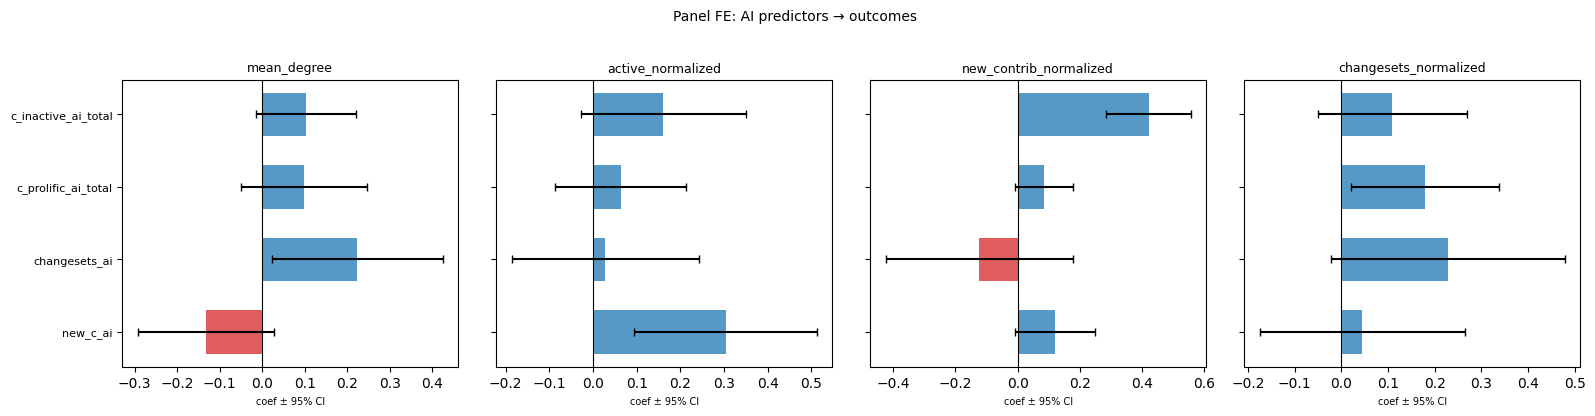

In [68]:
# ── Coefficient plot: all outcomes for one predictor set ─────────────────────
# One subplot per outcome, all predictors shown as horizontal bars.
# Bars not crossing zero = significant.
# Blue = positive association, red = negative.

SET_TO_PLOT = "AI"   # change to "Corporate" or "Humanitarian"

outcomes_fitted = [o for o in OUTCOMES if (SET_TO_PLOT, o) in all_results]
n = len(outcomes_fitted)


fig, axes = plt.subplots(
    1, n,
    figsize=(4 * n, 0.55 * len(PREDICTOR_SETS[SET_TO_PLOT]) + 2),
    sharey=True
)
if n == 1:
    axes = [axes]

for ax, outcome in zip(axes, outcomes_fitted):
    res, preds = all_results[(SET_TO_PLOT, outcome)]
    preds_in   = [p for p in preds if p in res.params.index]
    coefs  = [res.params[p] for p in preds_in]
    cis    = [res.std_errors[p] * 1.96 for p in preds_in]
    colors = ["tab:red" if c < 0 else "tab:blue" for c in coefs]

    ax.barh(range(len(preds_in)), coefs, xerr=cis,
            color=colors, alpha=0.75, capsize=3, height=0.6)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(range(len(preds_in)))
    ax.set_yticklabels(
        [p.replace("_share", "").replace("contributors_", "c_")
         for p in preds_in],
        fontsize=8
    )
    ax.set_title(outcome, fontsize=9)
    ax.set_xlabel("coef ± 95% CI", fontsize=7)

fig.suptitle(f"Panel FE: {SET_TO_PLOT} predictors → outcomes\n", fontsize=10)
plt.tight_layout()
#fig.savefig("../../results/statistical_evaluation/panelRegression_AIpredictors_23countries_v2.png", bbox_inches="tight")
plt.show()

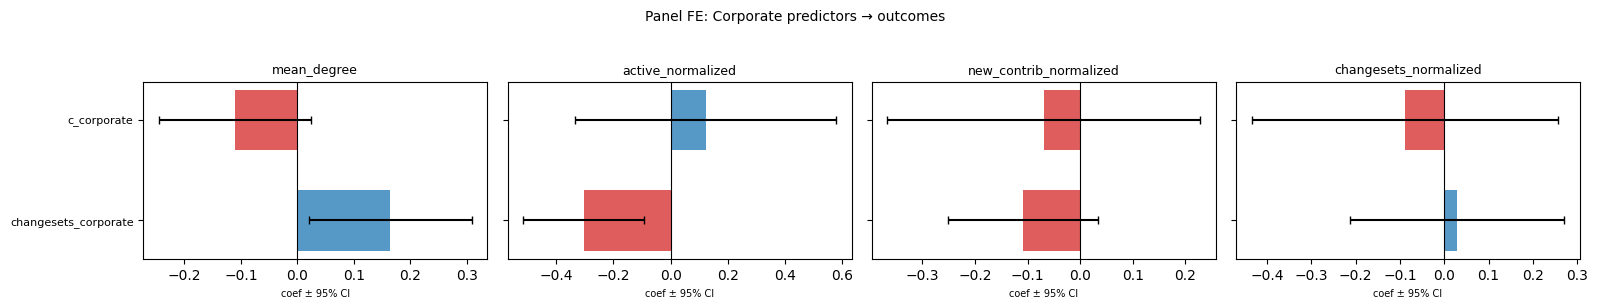

In [30]:
SET_TO_PLOT = "Corporate"   # change to "Corporate" or "Humanitarian"

outcomes_fitted = [o for o in OUTCOMES if (SET_TO_PLOT, o) in all_results]
n = len(outcomes_fitted)

if n == 0:
    print(f"No fitted models found for predictor set '{SET_TO_PLOT}'")
else:
    fig, axes = plt.subplots(
        1, n,
        figsize=(4 * n, 0.55 * len(PREDICTOR_SETS[SET_TO_PLOT]) + 2),
        sharey=True
    )
    if n == 1:
        axes = [axes]

    for ax, outcome in zip(axes, outcomes_fitted):
        res, preds = all_results[(SET_TO_PLOT, outcome)]
        preds_in   = [p for p in preds if p in res.params.index]
        coefs  = [res.params[p] for p in preds_in]
        cis    = [res.std_errors[p] * 1.96 for p in preds_in]
        colors = ["tab:red" if c < 0 else "tab:blue" for c in coefs]

        ax.barh(range(len(preds_in)), coefs, xerr=cis,
                color=colors, alpha=0.75, capsize=3, height=0.6)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_yticks(range(len(preds_in)))
        ax.set_yticklabels(
            [p.replace("_share", "").replace("contributors_", "c_")
             for p in preds_in],
            fontsize=8
        )
        ax.set_title(outcome, fontsize=9)
        ax.set_xlabel("coef ± 95% CI", fontsize=7)

    fig.suptitle(
        f"Panel FE: {SET_TO_PLOT} predictors → outcomes\n"
        #"(blue=positive, red=negative, bars crossing zero = not significant)"
    ,
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

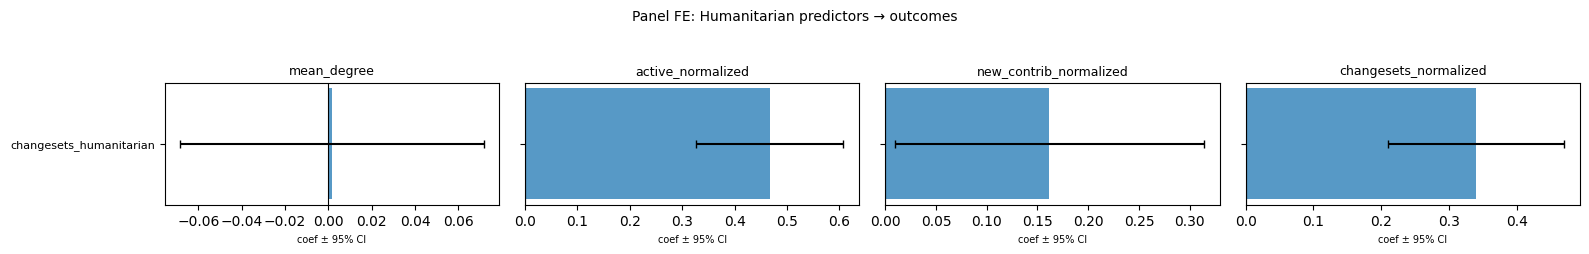

In [31]:
SET_TO_PLOT = "Humanitarian"   # change to "Corporate" or "Humanitarian"

outcomes_fitted = [o for o in OUTCOMES if (SET_TO_PLOT, o) in all_results]
n = len(outcomes_fitted)

if n == 0:
    print(f"No fitted models found for predictor set '{SET_TO_PLOT}'")
else:
    fig, axes = plt.subplots(
        1, n,
        figsize=(4 * n, 0.55 * len(PREDICTOR_SETS[SET_TO_PLOT]) + 2),
        sharey=True
    )
    if n == 1:
        axes = [axes]

    for ax, outcome in zip(axes, outcomes_fitted):
        res, preds = all_results[(SET_TO_PLOT, outcome)]
        preds_in   = [p for p in preds if p in res.params.index]
        coefs  = [res.params[p] for p in preds_in]
        cis    = [res.std_errors[p] * 1.96 for p in preds_in]
        colors = ["tab:red" if c < 0 else "tab:blue" for c in coefs]

        ax.barh(range(len(preds_in)), coefs, xerr=cis,
                color=colors, alpha=0.75, capsize=3, height=0.6)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_yticks(range(len(preds_in)))
        ax.set_yticklabels(
            [p.replace("_share", "").replace("contributors_", "c_")
             for p in preds_in],
            fontsize=8
        )
        ax.set_title(outcome, fontsize=9)
        ax.set_xlabel("coef ± 95% CI", fontsize=7)

    fig.suptitle(
        f"Panel FE: {SET_TO_PLOT} predictors → outcomes\n"
        #"(blue=positive, red=negative, bars crossing zero = not significant)"
    ,
        fontsize=10
    )
    plt.tight_layout()
    #fig.savefig("../../results/statistical_evaluation/panelRegression_HumanitarianPredictors_23countries_v2.png", bbox_inches="tight")
    plt.show()

In [69]:
# ── Config ────────────────────────────────────────────────────────────────────

PREDICTOR_LABELS = {
    "new_contributors_ai_share":           "New Contributor AI Share",
    "changesets_ai_share":               "Changesets AI Share",
    "contributors_inactive_share_ai_total": "Inactive Contributors AI Share (Total)",
    "contributors_prolific_share_ai_total":"Prolific Contributors AI Share (Total)",
    "contributors_corporate_share":        "Corporate Contributors Share",
     "changesets_corporate_share":        "Corporate Changesets Share",
    "changesets_humanitarian_share":     "Humanitarian Changesets Share",
}

OUTCOME_LABELS = {
    "mean_degree":            "Network Degree",
    "active_normalized":      "Active Contributors",
    "new_contrib_normalized": "New Contributors",
    "changesets_normalized":  "Changesets",
}

COLOR_POS = "tab:blue"
COLOR_NEG = "tab:red"

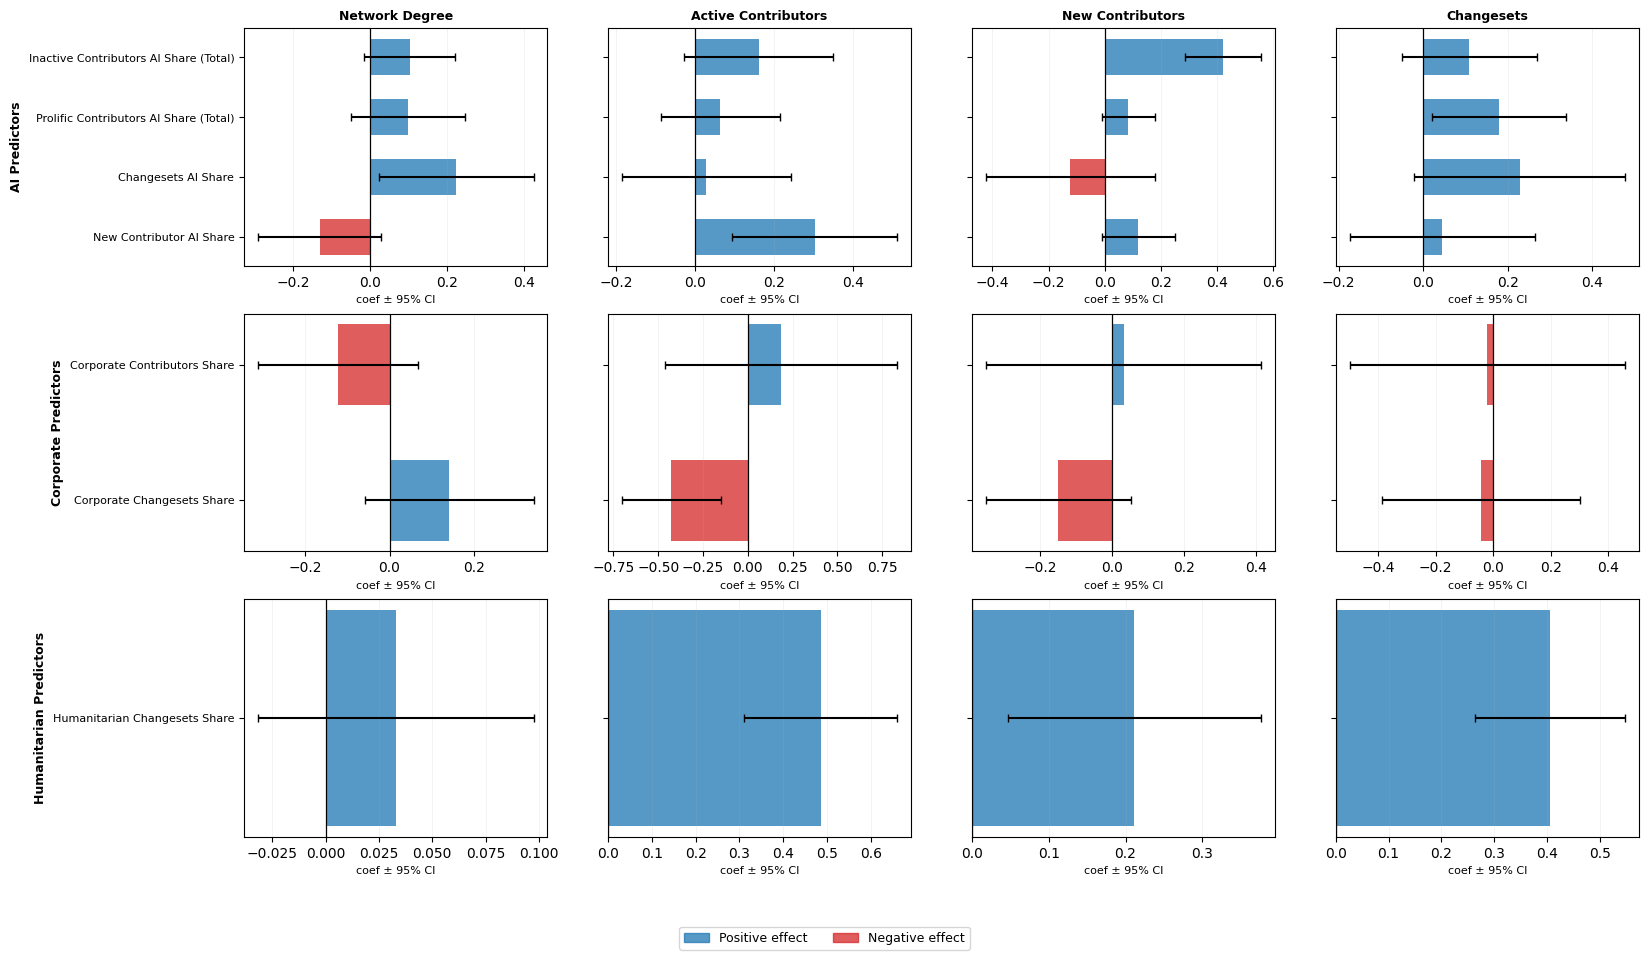

In [70]:
# ── Build layout: one row per predictor set, one column per outcome ───────────

n_rows = len(PREDICTOR_SETS)
n_cols = len(OUTCOMES)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4.5 * n_cols, 3.5 * n_rows),
   # gridspec_kw={"hspace": 0.55, "wspace": 0.35}
)

# ── AI row ────────────────────────────────────────────────────────────────────

for col_idx, outcome in enumerate(OUTCOMES):
    ax  = axes[0, col_idx]
    res, preds = all_results[("AI", outcome)]

    coefs  = [res.params[p]          for p in preds]
    cis    = [res.std_errors[p]*1.96 for p in preds]
    pvals  = [res.pvalues[p]         for p in preds]
    colors = [COLOR_POS if c > 0 else COLOR_NEG for c in coefs]
    labels = [PREDICTOR_LABELS.get(p, p) for p in preds]

    ax.barh(range(len(preds)), coefs, xerr=cis,
            color=colors, alpha=0.75, capsize=3, height=0.6)
    ax.axvline(0, color="black", linewidth=0.9)
    ax.set_yticks(range(len(preds)))
    ax.set_yticklabels(labels if col_idx == 0 else [""] * len(preds), fontsize=8)
    ax.set_title(OUTCOME_LABELS.get(outcome, outcome), fontsize=9, fontweight="bold")
    ax.set_xlabel("coef ± 95% CI", fontsize=8)
    ax.grid(axis="x", alpha=0.2, linewidth=0.5)

    if col_idx == 0:
        ax.set_ylabel("AI Predictors", fontsize=9, fontweight="bold")

# ── Corporate row ─────────────────────────────────────────────────────────────

for col_idx, outcome in enumerate(OUTCOMES):
    ax  = axes[1, col_idx]
    res, preds = all_results[("Corporate", outcome)]

    coefs  = [res.params[p]          for p in preds]
    cis    = [res.std_errors[p]*1.96 for p in preds]
    colors = [COLOR_POS if c > 0 else COLOR_NEG for c in coefs]
    labels = [PREDICTOR_LABELS.get(p, p) for p in preds]

    ax.barh(range(len(preds)), coefs, xerr=cis,
            color=colors, alpha=0.75, capsize=3, height=0.6)
    ax.axvline(0, color="black", linewidth=0.9)
    ax.set_yticks(range(len(preds)))
    ax.set_yticklabels(labels if col_idx == 0 else [""] * len(preds), fontsize=8)
    ax.set_xlabel("coef ± 95% CI", fontsize=8)
    ax.grid(axis="x", alpha=0.2, linewidth=0.5)

    if col_idx == 0:
        ax.set_ylabel("Corporate Predictors", fontsize=9, fontweight="bold")

# ── Humanitarian row ──────────────────────────────────────────────────────────

for col_idx, outcome in enumerate(OUTCOMES):
    ax  = axes[2, col_idx]
    res, preds = all_results[("Humanitarian", outcome)]

    coefs  = [res.params[p]          for p in preds]
    cis    = [res.std_errors[p]*1.96 for p in preds]
    colors = [COLOR_POS if c > 0 else COLOR_NEG for c in coefs]
    labels = [PREDICTOR_LABELS.get(p, p) for p in preds]

    ax.barh(range(len(preds)), coefs, xerr=cis,
            color=colors, alpha=0.75, capsize=3, height=0.6)
    ax.axvline(0, color="black", linewidth=0.9)
    ax.set_yticks(range(len(preds)))
    ax.set_yticklabels(labels if col_idx == 0 else [""] * len(preds), fontsize=8)
    ax.set_xlabel("coef ± 95% CI", fontsize=8)
    ax.grid(axis="x", alpha=0.2, linewidth=0.5)

    if col_idx == 0:
        ax.set_ylabel("Humanitarian Predictors", fontsize=9, fontweight="bold")

# ── Shared title and legend ───────────────────────────────────────────────────

legend_handles = [
    mpatches.Patch(color=COLOR_POS, alpha=0.75, label="Positive effect"),
    mpatches.Patch(color=COLOR_NEG, alpha=0.75, label="Negative effect"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=9,
           #bbox_to_anchor=(0.5, -0.02)
          )

#fig.suptitle("Panel Fixed-Effects Regression — all predictor sets\n" "Coefficients with 95% CI (blue = positive, red = negative)",fontsize=11, fontweight="bold", y=1.01)

#fig.savefig("../../results/statistical_evaluation/panelRegression_combined.png", bbox_inches="tight")
plt.show()

##### Checking changeset_comments_ai

In [34]:
# Check within-country variation of changeset_comments_ai
within_std = result_all_yearly.groupby("country")["changeset_comments_ai"].std()
between_std = result_all_yearly.groupby("country")["changeset_comments_ai"].mean().std()
print(f"Mean within-country std: {within_std.mean():.4f}")
print(f"Between-country std of means: {between_std:.4f}")
print(f"Ratio (within/between): {within_std.mean()/between_std:.2f}")
# If ratio > 1, within-country variation dominates -- FE estimates are reliable
# If ratio < 0.3, within-country variation is very low -- FE estimates are noisy

Mean within-country std: 7.7703
Between-country std of means: 49.1065
Ratio (within/between): 0.16


In [35]:
# Within/between ratio for all predictors
print(f"{'predictor':45s} {'within_std':>12s} {'between_std':>12s} {'ratio':>8s} {'ok?':>6s}")
print("-" * 85)

for col in ALL_PREDICTORS:
    if col not in result_all_yearly.columns:
        continue
    within_std   = result_all_yearly.groupby("country")[col].std().mean()
    between_std  = result_all_yearly.groupby("country")[col].mean().std()
    ratio        = within_std / between_std if between_std > 0 else 0
    flag         = "ok" if ratio >= 0.30 else "LOW -- review"
    print(f"  {col:43s} {within_std:>12.4f} {between_std:>12.4f} {ratio:>8.2f} {flag:>6s}")

predictor                                       within_std  between_std    ratio    ok?
-------------------------------------------------------------------------------------
  new_contributors_ai_share                         0.1190       0.1436     0.83     ok
  changesets_ai_share                               0.0534       0.0621     0.86     ok
  contributors_prolific_share_ai_total              0.0755       0.0625     1.21     ok
  contributors_inactive_share_ai_total              0.0355       0.0489     0.73     ok
  changesets_corporate_share                        0.0900       0.0903     1.00     ok
  contributors_corporate_share                      0.0539       0.0775     0.70     ok
  changesets_humanitarian_share                     0.0725       0.1770     0.41     ok


--> Here **changeset_comments_ai** was very low --> so it was excluded in the FE

### Slopes

In [71]:
# Run slopes for all your significant pairs
SLOPE_PAIRS = [
    ("changesets_ai_share", "mean_degree",   "Changesets AI Share → Network Degree"),
    ("contributors_inactive_share_ai_total", "mean_degree",   "Inactive Contributors AI Share (Total) → Network Degree"),
    ("contributors_inactive_share_ai_total","active_normalized",       "Inactive Contributors AI Share (Total) → Active Contributors"),
    ("new_contributors_ai_share","active_normalized",       "New Contributors AI Share → Active Contributors"),
    ("new_contributors_ai_share","new_contrib_normalized",       "New Contributors AI Share → New Contributors"),
    ("contributors_prolific_share_ai_total","new_contrib_normalized",       "Prolific Contributors AI Share (Total)→ New Contributors"),
    ("contributors_inactive_share_ai_total","new_contrib_normalized",       "Inactive Contributors AI Share (Total)→ New Contributors"),
    ("changesets_ai_share", "changesets_normalized",   "Changesets AI Share → Changesets"),
    ("contributors_prolific_share_ai_total","changesets_normalized",       "Prolific Contributors AI Share (Total)→ Changesets"),
    ("changesets_corporate_share", "active_normalized",  "Corporate Changesets Share → Active Contributors"),
    ("changesets_humanitarian_share", "active_normalized",  "Humanitarian Changesets Share → Active Contributors"),
    ("changesets_humanitarian_share", "new_contrib_normalized",  "Humanitarian Changesets Share → New Contributors"),
    ("changesets_humanitarian_share", "changesets_normalized",  "Humanitarian Changesets Share → Changesets"),
    ]

all_slopes = {}

for slope_pred, slope_outcome, label in SLOPE_PAIRS:
    country_slopes = []
    for country, grp in result_all_yearly.groupby("country"):
        sub = grp[[slope_pred, slope_outcome, "period"]].dropna()
        if len(sub) < 3:
            continue
        slope, intercept, r, p, se = sstats.linregress(
            pd.to_numeric(sub[slope_pred]),
            pd.to_numeric(sub[slope_outcome])
        )
        country_slopes.append({
            "country":   country,
            "slope":     round(slope, 4),
            "ci95":      round(se * 1.96, 4),
            "p":         round(p, 4),
            "r":         round(r, 4),
            "n_periods": len(sub),
            "mean_pred": round(sub[slope_pred].mean(), 4),
        })

    slopes_df = pd.DataFrame(country_slopes).sort_values("slope").reset_index(drop=True)
    all_slopes[label] = slopes_df

    n_pos = (slopes_df["slope"] > 0).sum()
    n_neg = (slopes_df["slope"] < 0).sum()
    n_sig = (slopes_df["p"] < 0.05).sum()
    print(f"\n{label}: {n_pos} positive, {n_neg} negative, {n_sig} significant")


Changesets AI Share → Network Degree: 16 positive, 9 negative, 5 significant

Inactive Contributors AI Share (Total) → Network Degree: 14 positive, 11 negative, 2 significant

Inactive Contributors AI Share (Total) → Active Contributors: 19 positive, 6 negative, 3 significant

New Contributors AI Share → Active Contributors: 20 positive, 5 negative, 6 significant

New Contributors AI Share → New Contributors: 20 positive, 5 negative, 4 significant

Prolific Contributors AI Share (Total)→ New Contributors: 16 positive, 9 negative, 3 significant

Inactive Contributors AI Share (Total)→ New Contributors: 18 positive, 7 negative, 8 significant

Changesets AI Share → Changesets: 15 positive, 10 negative, 5 significant

Prolific Contributors AI Share (Total)→ Changesets: 17 positive, 8 negative, 5 significant

Corporate Changesets Share → Active Contributors: 8 positive, 17 negative, 4 significant

Humanitarian Changesets Share → Active Contributors: 17 positive, 8 negative, 5 significant



In [263]:
summary = {
    "n_countries": len(slopes_df),
    "n_positive": (slopes_df["slope"] > 0).sum(),
    "n_negative": (slopes_df["slope"] < 0).sum(),
    "median_slope": slopes_df["slope"].median(),
    "mean_slope": slopes_df["slope"].mean(),
    "q25_slope": slopes_df["slope"].quantile(0.25),
    "q75_slope": slopes_df["slope"].quantile(0.75),
    "min_slope": slopes_df["slope"].min(),
    "max_slope": slopes_df["slope"].max(),
    "n_significant": (slopes_df["p"] < 0.05).sum(),
}

In [35]:
17/31

0.5483870967741935

In [266]:
summary

{'n_countries': 31,
 'n_positive': np.int64(20),
 'n_negative': np.int64(11),
 'median_slope': np.float64(0.4033),
 'mean_slope': np.float64(-64.95241290322579),
 'q25_slope': np.float64(-0.59605),
 'q75_slope': np.float64(0.8284),
 'min_slope': np.float64(-2084.4653),
 'max_slope': np.float64(376.0369),
 'n_significant': np.int64(6)}

In [271]:
check = (
    result_all_yearly
    .groupby("country")["changesets_humanitarian_share"]
    .agg(["std", "min", "max"])
    .sort_values("std")
)

print(check)

              std       min       max
country                              
HUN      0.000057  0.000000  0.000150
B35      0.000063  0.000000  0.000129
CYP      0.000083  0.000000  0.000200
MKD      0.000133  0.000000  0.000325
MNE      0.000149  0.000000  0.000365
SAU      0.000514  0.000000  0.001421
NZ1      0.000992  0.000000  0.002497
US1      0.001143  0.000060  0.002885
GRC      0.001636  0.000000  0.003834
BRN      0.001753  0.000000  0.004682
BOL      0.011087  0.000000  0.028618
VNM      0.012331  0.018167  0.046930
ALB      0.017201  0.000000  0.043075
KHM      0.027517  0.000000  0.068860
KOR      0.029833  0.000000  0.069696
URY      0.046195  0.000159  0.096657
TUR      0.060837  0.001690  0.166984
IND      0.071698  0.035639  0.196633
SLE      0.089825  0.002393  0.238940
TZA      0.107174  0.322447  0.605759
NGA      0.112534  0.459766  0.723015
LAO      0.129950  0.003715  0.347996
ETH      0.132749  0.140210  0.450608
KEN      0.134439  0.346965  0.705654
AFG      0.1

In [28]:
all_slopes = {}

for slope_pred, slope_outcome, label in SLOPE_PAIRS:
    
    country_slopes = []

    for country, grp in result_all_yearly.groupby("country"):
        
        sub = grp[[slope_pred, slope_outcome, "period"]].dropna()

        if len(sub) < 3:
            continue

        # Within-country variation in the predictor
        predictor_sd = sub[slope_pred].std()

        slope, intercept, r, p, se = sstats.linregress(
            pd.to_numeric(sub[slope_pred]),
            pd.to_numeric(sub[slope_outcome])
        )

        country_slopes.append({
            "country": country,
            "slope": round(slope, 4),
            "ci95": round(se * 1.96, 4),
            "p": round(p, 4),
            "r": round(r, 4),
            "n_periods": len(sub),
            "mean_pred": round(sub[slope_pred].mean(), 4),
            "predictor_sd": round(predictor_sd, 4)
        })

    slopes_df = (
        pd.DataFrame(country_slopes)
        .sort_values("slope")
        .reset_index(drop=True)
    )

    all_slopes[label] = slopes_df

    n_pos = (slopes_df["slope"] > 0).sum()
    n_neg = (slopes_df["slope"] < 0).sum()
    n_sig = (slopes_df["p"] < 0.05).sum()

    print(
        f"\n{label}: "
        f"{n_pos} positive, "
        f"{n_neg} negative, "
        f"{n_sig} significant"
    )


Changesets AI Share → Network Degree: 21 positive, 10 negative, 5 significant

Changesets AI Share → Changesets: 20 positive, 11 negative, 5 significant

Inactive Contributors AI Share (Total)→ Active Contributors: 23 positive, 8 negative, 3 significant

Inactive Contributors AI Share (Total)→ New Contributors: 21 positive, 10 negative, 8 significant

Prolific Contributors AI Share (Total)→ New Contributors: 21 positive, 10 negative, 4 significant

Prolific Contributors AI Share (Total)→ Network Degree: 21 positive, 10 negative, 8 significant

New Contributors AI Share→ Active Contributors: 25 positive, 6 negative, 6 significant

Prolific Contributors AI Share (Total)→ Changesets: 21 positive, 10 negative, 5 significant

Corporate Changesets Share → Network Degree: 21 positive, 10 negative, 8 significant

Corporate Changesets Share → Active Contributors: 12 positive, 19 negative, 4 significant

Humanitarian Changesets Share → Active Contributors: 22 positive, 9 negative, 7 significant

In [29]:
for label, df in all_slopes.items():
    print(f"\n{label}")
    print("Countries:", len(df))
    print("Positive:", (df["slope"] > 0).sum())
    print("Negative:", (df["slope"] < 0).sum())
    print("Significant:", (df["p"] < 0.05).sum())
    print("Median slope:", df["slope"].median())
    print("IQR:", df["slope"].quantile(.25), "-", df["slope"].quantile(.75))
    print("Low variation (SD < .01):", (df["predictor_sd"] < .01).sum())


Changesets AI Share → Network Degree
Countries: 31
Positive: 21
Negative: 10
Significant: 5
Median slope: 0.2345
IQR: -0.07295 - 0.4587
Low variation (SD < .01): 1

Changesets AI Share → Changesets
Countries: 31
Positive: 20
Negative: 11
Significant: 5
Median slope: 0.3686
IQR: -0.6773 - 1.4378
Low variation (SD < .01): 1

Inactive Contributors AI Share (Total)→ Active Contributors
Countries: 31
Positive: 23
Negative: 8
Significant: 3
Median slope: 1.4566
IQR: -0.0751 - 6.75565
Low variation (SD < .01): 10

Inactive Contributors AI Share (Total)→ New Contributors
Countries: 31
Positive: 21
Negative: 10
Significant: 8
Median slope: 0.9389
IQR: -0.1407 - 4.5715
Low variation (SD < .01): 10

Prolific Contributors AI Share (Total)→ New Contributors
Countries: 31
Positive: 21
Negative: 10
Significant: 4
Median slope: 0.2352
IQR: -0.0978 - 0.79915
Low variation (SD < .01): 2

Prolific Contributors AI Share (Total)→ Network Degree
Countries: 31
Positive: 21
Negative: 10
Significant: 8
Median

In [268]:
slopes_df.sort_values("slope").head(5)
slopes_df.sort_values("slope").tail(5)

,country,slope,ci95,p,r,n_periods,mean_pred
26,BOL,3.9940,5.9064,0.2557,0.5524,6,0.0101
27,BRN,7.4212,52.9249,0.7971,0.1361,6,0.0014
28,US1,37.2349,177.1120,0.7014,0.2018,6,0.0010
29,CYP,43.7888,1678.6586,0.9617,0.0256,6,0.0001
30,B35,376.0369,3003.7852,0.8182,0.1218,6,0.0000


In [255]:
all_slopes["Changesets AI Share → Network Degree"]

,country,slope,ci95,p,r,n_periods,mean_pred
0,GRC,-1.6981,4.4461,0.4957,-0.3506,6,0.0279
1,NZ1,-0.8345,0.9407,0.1571,-0.6561,6,0.0410
2,MNE,-0.3114,1.1645,0.6279,-0.2535,6,0.0181
3,BOL,-0.2630,0.4960,0.3575,-0.4610,6,0.1455
4,MKD,-0.1899,0.4353,0.4406,-0.3932,6,0.0179
5,PNG,-0.1709,0.3317,0.3697,-0.4507,6,0.1459
6,ALB,-0.1259,0.1741,0.2295,-0.5780,6,0.0530
7,AFG,-0.1153,0.6144,0.7317,-0.1809,6,0.0286
8,ETH,-0.0306,0.3606,0.8760,-0.0829,6,0.0471
9,SAU,-0.0068,0.9252,0.9893,-0.0072,6,0.0271


In [269]:
country = slopes_df.sort_values("slope").iloc[0]["country"]

result_all_yearly[
    result_all_yearly["country"] == country
][[
    "period",
    "changesets_ai_share",
    "changesets_normalized"
]]

,period,changesets_ai_share,changesets_normalized
72,2025,0.017154,0.427374
73,2024,0.076338,0.541236
74,2023,0.074052,0.482332
75,2022,0.029151,0.388482
76,2021,0.000319,0.368580
77,2020,0.001197,0.107252


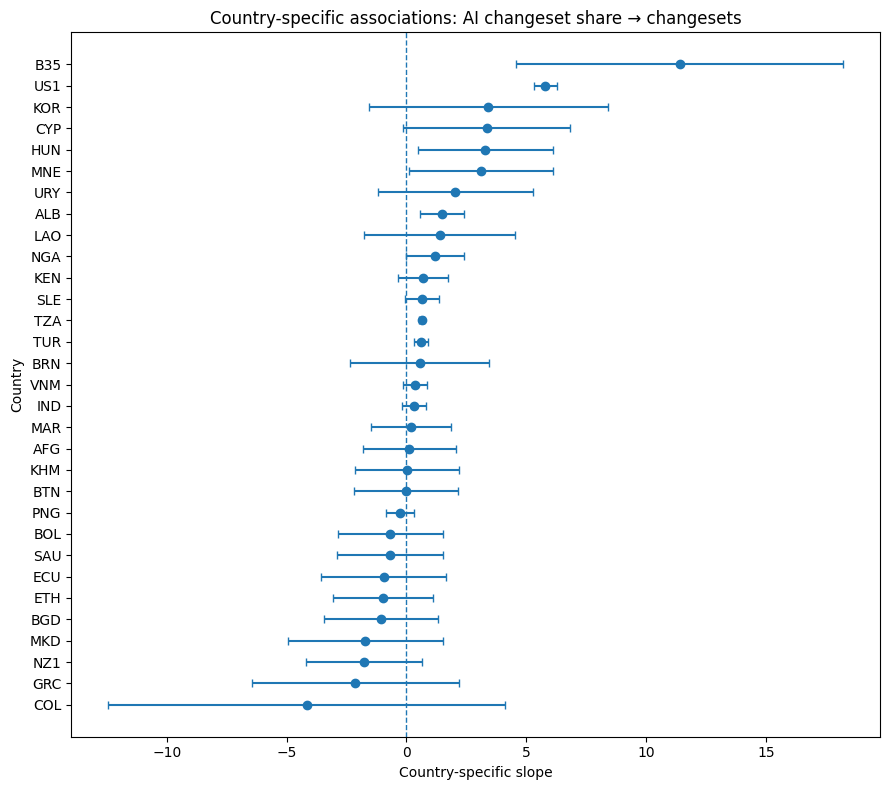

In [265]:
df = all_slopes["Changesets AI Share → Changesets"].copy()

df = df.sort_values("slope")

y = np.arange(len(df))

plt.figure(figsize=(9, 8))

plt.errorbar(
    df["slope"],
    y,
    xerr=df["ci95"],
    fmt="o",
    capsize=3
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.yticks(y, df["country"])
plt.xlabel("Country-specific slope")
plt.ylabel("Country")
plt.title("Country-specific associations: AI changeset share → changesets")

plt.tight_layout()
plt.show()